In [3]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
import matplotlib.pyplot as plt 
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense,Dropout 
from keras.optimizers import Adam 
from sklearn.model_selection import train_test_split as tts 
from sklearn.metrics import mean_squared_error

In [4]:
# Generating data
X_train = np.linspace(-1,1,20)

y_train = np.array([-0.6561, -0.3099,-0.59035,-0.50855, -0.285, 
                    -0.2443, -0.02445, -0.00135, -0.2006, 0.07475,
                    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415, 
                    0.5524, 0.23115, 0.20835, 0.4211, 0.60485])

X_test = np.linspace(-1,1,20)

y_test = np.array([-0.69415, -0.451, -0.43005, -0.4484, -0.1475,
                   -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
                   0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
                   0.3639, 0.5536, 0.3365, 0.50705, 0.33435])

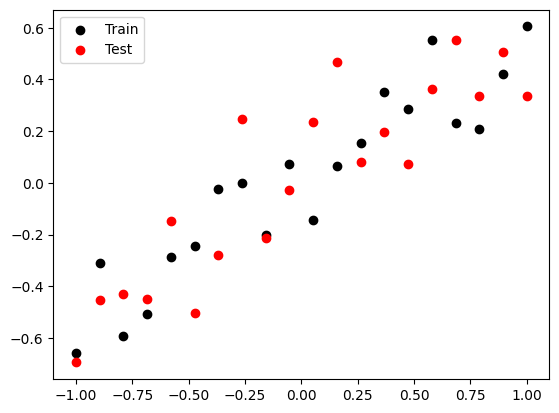

In [5]:
plt.scatter(X_train,y_train, c='black', label='Train')
plt.scatter(X_test,y_test, c='red', label='Test')
plt.legend()
plt.show()

In [7]:
# Data is linear 
# so we will apply regression

In [8]:
# Regression model 
model = Sequential()

model.add(Dense(10, input_dim=1, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))


adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])
history = model.fit(X_train,y_train, epochs=500, validation_data=(X_test,y_test),verbose=False)

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Evaluate the model

_, train_mse = model.evaluate(X_train,y_train,verbose=0)
_, test_mse = model.evaluate(X_test,y_test,verbose=0)
print(f'Train: {train_mse}, Test : {test_mse}')

Train: 0.006095427088439465, Test : 0.044614773243665695


In [10]:
y_pred = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


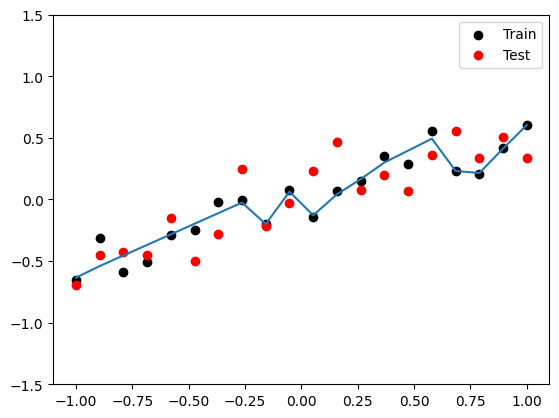

In [11]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

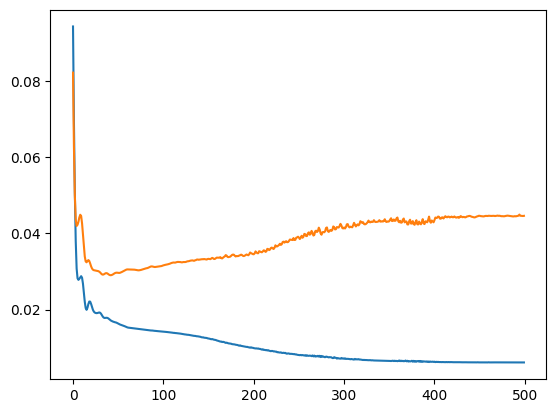

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [20]:
# Dropout Model 

model = Sequential()
model.add(Dense(10,input_dim=1,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))
adam = Adam(learning_rate=0.01)

model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model.fit(X_train,X_test, validation_data=(X_test,y_test), epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.4634 - mse: 0.4634 - val_loss: 0.2330 - val_mse: 0.2330
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.7649 - mse: 0.7649 - val_loss: 0.1949 - val_mse: 0.1949
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.5432 - mse: 0.5432 - val_loss: 0.1661 - val_mse: 0.1661
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.3044 - mse: 0.3044 - val_loss: 0.1462 - val_mse: 0.1462
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.4270 - mse: 0.4270 - val_loss: 0.1300 - val_mse: 0.1300
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.6427 - mse: 0.6427 - val_loss: 0.1154 - val_mse: 0.1154
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.4119 - mse: 0.4119 - val_loss: 0.1029 - val_mse: 0.1029
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.5852 - mse: 0.5852 - val_loss: 0.0916 - val_mse: 0.0916
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.3110 -

In [21]:
# Evaluate the model

_, train_mse = model.evaluate(X_train,y_train,verbose=0)
_, test_mse = model.evaluate(X_test,y_test,verbose=0)
print(f'Train: {train_mse}, Test : {test_mse}')

Train: 0.021399833261966705, Test : 0.03344506770372391


In [22]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


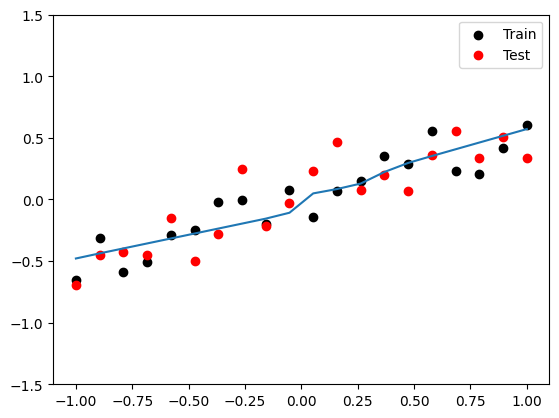

In [23]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

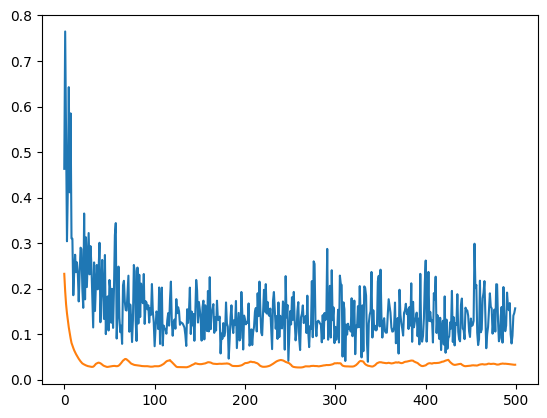

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])